# Image Denoising using Autoencoder on MNIST Dataset

## Introduction

Image denoising is a fundamental task in computer vision that aims to recover clean images from noisy or corrupted inputs. Noise can be introduced during image acquisition, transmission, or storage, leading to degradation in image quality and making further image analysis more challenging.

In this project, a deep learning-based **Denoising Autoencoder** is implemented using **TensorFlow** and **Keras** to remove Gaussian noise from handwritten digit images in the **MNIST** dataset. An autoencoder is an unsupervised neural network that learns a compressed representation (latent space) of the input data and reconstructs it as accurately as possible. By training the network with noisy images as input and clean images as target output, the model learns to distinguish meaningful image features from noise.

The workflow includes loading and preprocessing the MNIST dataset, artificially adding Gaussian noise, designing and training a fully connected autoencoder, evaluating its reconstruction performance, and comparing the original, noisy, and denoised images. Additionally, quantitative evaluation metrics such as Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR) are used to assess the model's effectiveness.

This project demonstrates the practical application of autoencoders in image restoration and serves as an introduction to representation learning and unsupervised deep learning techniques.

Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Input layer
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_img, outputs=decoded)

Load MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Normalize Images

In [3]:
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

In [4]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

Adding Gaussian Noise

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

Autoencoder

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

Training

In [7]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    validation_data=(x_test_noisy,x_test),
    epochs=20,
    batch_size=256,
    shuffle=True
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.2667 - val_loss: 0.2089
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1885 - val_loss: 0.1732
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1665 - val_loss: 0.1598
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1572 - val_loss: 0.1527
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1510 - val_loss: 0.1474
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1460 - val_loss: 0.1437
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1425 - val_loss: 0.1403
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1395 - val_loss: 0.1375
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1372 - val_loss: 0.1352
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1350 - val_loss: 0.1334
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1332 - val_loss: 0.1320
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Evaluating the Model**

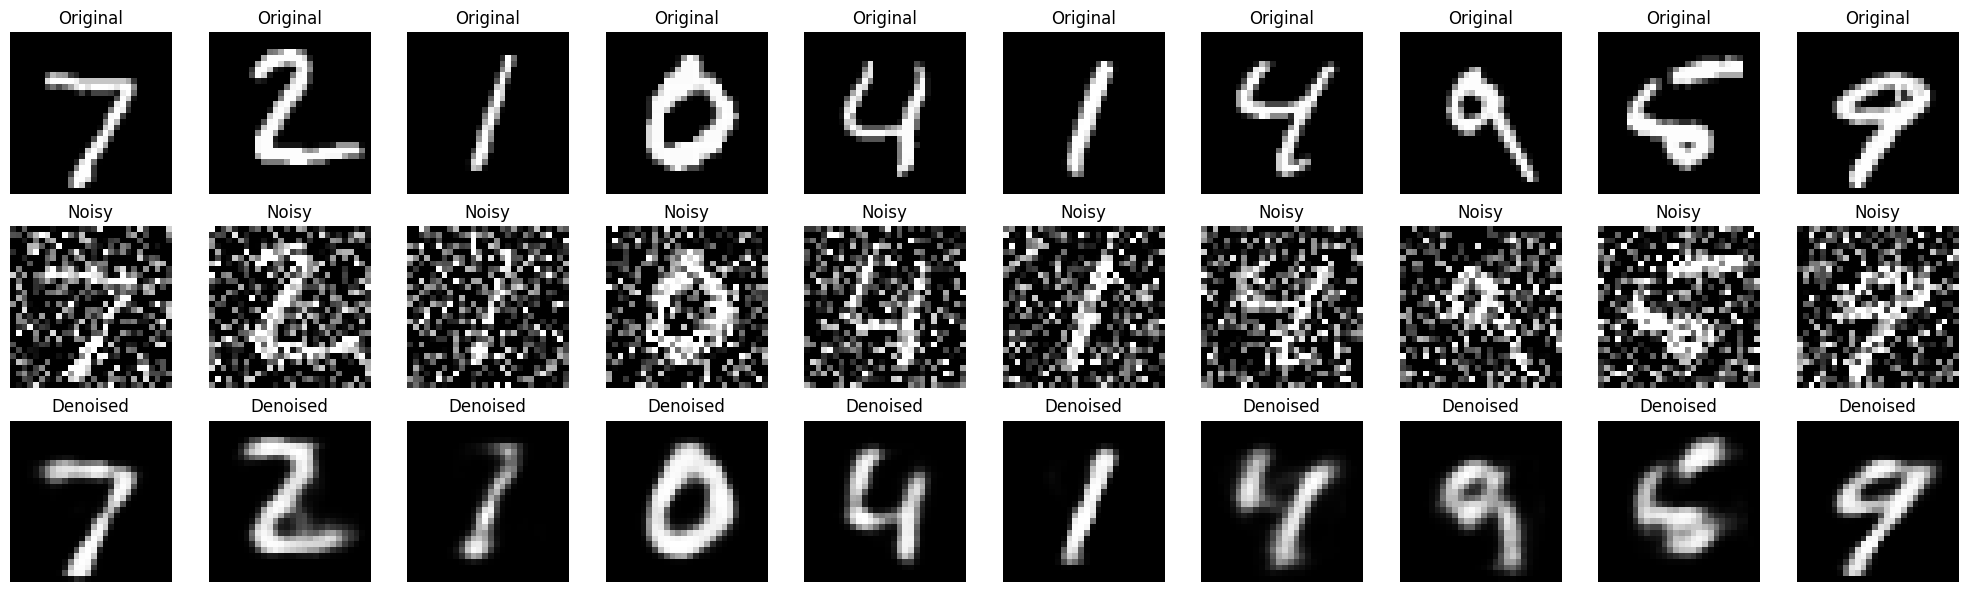

In [9]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

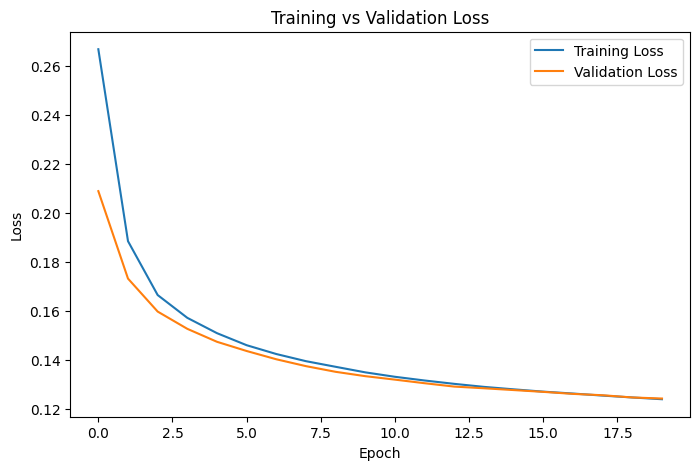

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [11]:
loss = autoencoder.evaluate(x_test_noisy, x_test)

print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1243
Test Loss: 0.12430685013532639


In [12]:
plt.savefig("comparison.png", dpi=300)
plt.savefig("loss_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [13]:
autoencoder.save("denoising_autoencoder.keras")

## Conclusion

In this project, a denoising autoencoder was successfully developed using TensorFlow and trained on the MNIST handwritten digit dataset. Gaussian noise was intentionally added to the images, and the model learned to reconstruct clean images from these noisy inputs by learning meaningful latent representations.

The trained autoencoder effectively reduced image noise while preserving the essential structure and features of the handwritten digits. Both qualitative visual comparisons and quantitative evaluation metrics demonstrated that the model was able to generate denoised images that closely resembled the original images.

This project highlights the effectiveness of autoencoders for image denoising and demonstrates how deep learning models can learn robust feature representations without requiring labeled data. The techniques explored in this project can be extended to more advanced architectures, such as Convolutional Autoencoders and Variational Autoencoders, and applied to real-world image restoration tasks involving medical imaging, satellite imagery, and low-light photography.